# SWE-E2E v2 dump browser

Browses everything dumped by the vLLM / MINF SingleController runs under
`/scratch/fsw/portfolios/nemotron/projects/nemotron_sw_post/users/rkirby/runs/<EXP>/`:

| what | where | granularity |
|---|---|---|
| rollout dumps | `dumps/rollouts/target_step_NNNNN.jsonl` (~10 GB/step) | one JSON per rollout: ids, reward, per-message token counts, the full Gym result (every turn's text, tool calls, per-turn token usage, timings, error kind) |
| token-level dumps | `dumps/token_level/step_NNNNN_chunk_NNN.pt` | per sequence: input_ids, token_mask, generation logprobs, trainer logprobs, advantages, rewards, sample masks |
| precomputed summaries | `swe_dump/analysis/rollouts/*.summary.jsonl`, `analysis/tokens/*.rows.csv`, `*.hist.json` | one row per rollout / sequence (fast to load) |
| W&B scalars (cached) | `analysis/wandb_*.json` | per train step |
| Gym per-instance results (runs without dumps, e.g. the main MINF chain) | `swe_minf/nemo_rl/3rdparty/Gym-workspace/Gym/results/swebench_results_<session>/<instance>_<ts>_<uuid>/nemo_gym_metrics.json` | one dir per rollout |

Naming: rollout files are keyed by **target_step k**, which feeds **train step k+1**; token-level files and W&B use the train step.
All helpers below take the train step.

Reports already written: `analysis/aggregate_report.md`, `analysis/deep_report.md`, `analysis/ab/` (parser A/B), `analysis/early_steps/report.md`.
Regenerate summaries for new steps/runs (CPU job templates in `analysis/logs/*.sbatch`):

```
python3 tools/rollout_summary.py analysis/rollouts <run_dir>/dumps/rollouts/target_step_*.jsonl
python3 tools/token_level_summary.py analysis/tokens <run_dir>/dumps/token_level/step_*_chunk_*.pt
```


In [3]:
import os, sys, json, glob, re, statistics as st
from collections import Counter, defaultdict
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 80); pd.set_option("display.max_colwidth", 140)
try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except Exception:
    HAVE_MPL = False
    print("matplotlib not available: tables only")

W = "/scratch/fsw/portfolios/nemotron/projects/nemotron_sw_post/users/rkirby/workspaces/swe_dump"
RUNS_ROOT = "/scratch/fsw/portfolios/nemotron/projects/nemotron_sw_post/users/rkirby/runs"
ANALYSIS = f"{W}/analysis"
GYM_MAIN = "/scratch/fsw/portfolios/nemotron/projects/nemotron_sw_post/users/rkirby/workspaces/swe_minf/nemo_rl/3rdparty/Gym-workspace/Gym/results"
sys.path.insert(0, f"{W}/tools")
from pt_numpy import load as load_pt   # torch-free loader for the .pt dumps

RUNS = {
    "runA_vllm": "nano35-swe-v2-stream128-inorder1-cmh-64n-vllm_dump-20260918",
    "runB_minf": "nano35-swe-v2-stream128-inorder1-cmh-64n-minf_dump-from10-20260918",
    "chainC_minf_nopg_noprefix": "nano35-swe-v2-stream128-inorder1-cmh-64n-minf_dump-nopg-noprefix-20260919",
    "chainD_vllm_from10_nopg": "nano35-swe-v2-stream128-inorder1-cmh-64n-vllm_dump-from10-nopg-20260919",
    "main_minf": "nano35-swe-v2-stream128-inorder1-cmh-64n-minf",
}
EXP2RUN = {v: k for k, v in RUNS.items()}

def run_dir(run):
    return f"{RUNS_ROOT}/{RUNS.get(run, run)}"

def rollout_files(run):
    return sorted(glob.glob(f"{run_dir(run)}/dumps/rollouts/target_step_*.jsonl"))

def token_files(run, train_step=None):
    pat = f"step_{train_step:05d}_chunk_*.pt" if train_step is not None else "step_*_chunk_*.pt"
    return sorted(glob.glob(f"{run_dir(run)}/dumps/token_level/{pat}"))

def step_of(path):
    m = re.search(r"(?:target_step|step)_(\d+)", os.path.basename(path))
    return int(m.group(1)) if m else None


## Inventory

In [4]:
def inventory():
    rows = []
    for run in RUNS:
        d = run_dir(run); rf = rollout_files(run); tf = token_files(run)
        ck = sorted(int(p.rsplit("_", 1)[1]) for p in glob.glob(f"{d}/checkpoints/step_*") if p.rsplit("_", 1)[1].isdigit())
        rows.append(dict(run=run,
                         rollout_train_steps=f"{step_of(rf[0]) + 1}-{step_of(rf[-1]) + 1}" if rf else "-", rollout_files=len(rf),
                         rollout_GB=round(sum(os.path.getsize(p) for p in rf) / 1e9, 1),
                         token_train_steps=f"{step_of(tf[0])}-{step_of(tf[-1])}" if tf else "-", token_chunks=len(tf),
                         token_GB=round(sum(os.path.getsize(p) for p in tf) / 1e9, 1),
                         checkpoints=ck[-6:], gym_sessions=len(glob.glob(f"{d}/gym_results/*"))))
    return pd.DataFrame(rows)

inventory()


,run,rollout_train_steps,rollout_files,rollout_GB,token_train_steps,token_chunks,token_GB,checkpoints,gym_sessions
0,runA_vllm,1-24,24,248.5,1-24,69,18.6,"[5, 10, 15, 20, 23]",6
1,runB_minf,11-30,20,223.6,11-29,49,15.2,"[10, 15, 20, 25, 28]",6
2,chainC_minf_nopg_noprefix,11-18,8,77.5,11-17,18,5.3,"[10, 15, 16]",4
3,chainD_vllm_from10_nopg,11-11,1,0.0,-,0,0.0,[10],2
4,main_minf,-,0,0.0,-,0,0.0,"[35, 40, 45, 50, 55, 58]",0


## Precomputed per-rollout and per-sequence summaries

Fast path: one row per rollout (`R`) and one row per trained sequence (`T`). Join on `sample_id`.

In [5]:
def load_rollout_summaries(pattern="*"):
    recs = []
    for f in sorted(glob.glob(f"{ANALYSIS}/rollouts/{pattern}.summary.jsonl")):
        with open(f) as fh:
            recs.extend(json.loads(line) for line in fh if line.strip())
    R = pd.DataFrame(recs)
    R = R[R["sample_id"].notna()].copy()
    R["train_step"] = R["target_step"].astype(int) + 1
    R["short_run"] = R["run"].map(EXP2RUN).fillna(R["run"])
    R["engine"] = np.where(R["run"].str.contains("vllm"), "vllm", "minf")
    R["truncated"] = R["truncated"].fillna(False).astype(bool)
    return R

def load_token_rows(pattern="*"):
    files = sorted(glob.glob(f"{ANALYSIS}/tokens/{pattern}.rows.csv"))
    T = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    T["train_step"] = T["file"].str.extract(r"step_(\d+)").astype(int)
    T["short_run"] = T["run"].map(EXP2RUN).fillna(T["run"])
    T["engine"] = np.where(T["run"].str.contains("vllm"), "vllm", "minf")
    return T

R = load_rollout_summaries()
T = load_token_rows()
print("rollouts", R.shape, " sequences", T.shape)
R.groupby("short_run")["train_step"].agg(["min", "max", "count"])


rollouts (25344, 70)  sequences (25072, 29)


,min,max,count
short_run,,,
chainC_minf_nopg_noprefix,11,18,3600
chainD_vllm_from10_nopg,11,11,16
runA_vllm,1,24,11408
runB_minf,11,30,10320


In [6]:
R[R['n_gen_without_think_close'] > 0]

,sample_id,group_id,target_step,completion_index,prompt_idx,instance_id,dataset,start_wv,end_wv,reward,truncated,turns,gen_len,total_tokens,prompt_tokens,max_asst_tokens,sum_user_tokens,n_invalid_tool_call,n_malformed_thinking,resolved,patch_exists,model_patch_len,agent_error_kind,agent_timed_out,eval_timed_out,oom_killed,eval_oom_killed,openhands_run_time,total_model_call_time,total_command_exec_time,final_eval_time,usage_prompt_tokens,usage_completion_tokens,usage_cache_read_tokens,ptm_keys,n_latencies,latency_max,latency_sum,resp_status,resp_error,resp_incomplete,mask_sample,agent_max_turns,n_out_items,n_reasoning,n_message,n_message_nonblank,n_function_call,n_function_call_output,fc_names,n_finish,last_item_type,last_item_name,last_gen_has_tool_call,last_gen_has_im_end,n_gen_without_im_end,n_gen_without_think_close,max_gen_chars,item_statuses,rm_natural_termination_rate,rm_truncation_rate,rm_max_turns_reached_rate,rm_turns_mean,rm_max_gen_tokens_per_turn_max,committed_at,run,file,train_step,short_run,engine
15,ca5ec6a7-c714-4399-bd28-87a3ed54dbb5_g15,ca5ec6a7-c714-4399-bd28-87a3ed54dbb5,10,15,360,elastic__go-libaudit-67,nebius/SWE-rebench-V2,10,10,1.0,False,24,5706,24966,5697,1282,19260,0,0,True,True,2614,NaN,None,None,None,None,142.407585,72.381296,9.279936,11.286882,332704.0,5706.0,308736.0,"[accumulated_cost, accumulated_token_usage, action_execution_latencies, condenser, costs, max_budget_per_task, response_latencies, token...",24,16.912348,71.784085,None,None,None,False,200,97,24,24,15,25,24,"{'execute_bash': 18, 'str_replace_editor': 6, 'finish': 1}",1,function_call,finish,True,True,1,1,5795,{'completed': 73},1.0000,0.0000,None,36.3125,2660.0,1.789772e+09,nano35-swe-v2-stream128-inorder1-cmh-64n-minf_dump-from10-20260918,target_step_00010,11,runB_minf,minf
450,51f7288a-bc17-489c-a001-325ece44b828_g2,51f7288a-bc17-489c-a001-325ece44b828,10,2,357,dbt-labs__dbt-snowflake-1289,nebius/SWE-rebench-V2,10,10,0.0,False,150,40074,108655,5879,1637,68581,0,0,False,True,918,NaN,None,None,None,None,793.377812,532.987589,164.381513,29.441957,9225102.0,40074.0,8898816.0,"[accumulated_cost, accumulated_token_usage, action_execution_latencies, condenser, costs, max_budget_per_task, response_latencies, token...",150,16.580998,456.509476,None,None,None,False,200,605,150,150,0,153,152,"{'execute_bash': 133, 'str_replace_editor': 18, 'think': 1, 'finish': 1}",1,function_call,finish,True,True,3,3,6829,{'completed': 455},1.0000,0.0000,None,126.5000,1637.0,1.789774e+09,nano35-swe-v2-stream128-inorder1-cmh-64n-minf_dump-from10-20260918,target_step_00010,11,runB_minf,minf
475,d716d26a-4106-4b95-ae3b-e759470efa0f_g11,d716d26a-4106-4b95-ae3b-e759470efa0f,10,11,361,laravel-shift__blueprint-403,nebius/SWE-rebench-V2,10,10,0.0,False,135,39526,92345,5967,2267,52819,0,0,False,True,758,NaN,None,None,None,None,677.114121,533.230921,51.511572,7.126174,6842705.0,39526.0,6739456.0,"[accumulated_cost, accumulated_token_usage, action_execution_latencies, condenser, costs, max_budget_per_task, response_latencies, token...",135,22.115121,484.896908,None,None,None,False,200,541,135,135,0,136,135,"{'execute_bash': 102, 'str_replace_editor': 33, 'finish': 1}",1,function_call,finish,True,True,1,1,10079,{'completed': 406},1.0000,0.0000,None,138.8750,4582.0,1.789774e+09,nano35-swe-v2-stream128-inorder1-cmh-64n-minf_dump-from10-20260918,target_step_00010,11,runB_minf,minf
704,ac298e1c-4cb7-4f9e-969a-e389a9193125_g0,ac298e1c-4cb7-4f9e-969a-e389a9193125,11,0,396,instance_apache__cordova-ios-ff69ddd1e6aa33888cbf5ce3c2625d0d9827b523,nv-internal-1,10,10,0.0,False,57,17055,44386,6046,1934,27331,0,0,False,True,1604,NaN,None,None,None,None,342.123596,260.849611,33.039448,8.799325,1539466.0,17055.0,1456128.0,"[accumulated_cost, accumulated_token_usage, action_execution_latencies, condenser, costs, max_budget_per_task, response_latencies, token...",57,25.282352,255.756439,None,None,None,False,200,229,57,57,0,58,57,"{'execute_bash': 40, 'str_replace_editor': 13, 'task_tracker'

### Per-step aggregates

In [7]:
def per_step(R):
    g = R.groupby(["short_run", "train_step"])
    out = pd.DataFrame({
        "n": g.size(), "reward": g["reward"].mean(),
        "gen_len_mean": g["gen_len"].mean(), "gen_len_p50": g["gen_len"].median(), "gen_len_p95": g["gen_len"].quantile(0.95),
        "trunc_rate": g["truncated"].mean(), "turns_mean": g["turns"].mean(), "max_turn_tokens_mean": g["max_asst_tokens"].mean(),
        "ctx_window_rate": g["agent_error_kind"].apply(lambda s: (s == "context_window").mean()),
        "max_iter_rate": g["agent_error_kind"].apply(lambda s: (s == "max_iteration").mean()),
    })
    return out.round(3)

PS = per_step(R)
PS


n  reward  gen_len_mean  gen_len_p50  gen_len_p95  trunc_rate  turns_mean  max_turn_tokens_mean  ctx_window_rate  max_iter_rate
short_run                 train_step                                                                                                                                    
chainC_minf_nopg_noprefix 11           512   0.316     28559.242      26599.5     59326.00       0.008     100.963              3169.631            0.037          0.045
                          12           512   0.355     29002.066      24505.5     58300.50       0.021      94.756              4094.473            0.043          0.055
                          13           512   0.252     31783.443      30257.5     61227.40       0.016     112.279              3693.377            0.027          0.080
                          14           512   0.273     26989.650      23211.0     59059.80       0.008      91.785              3328.773            0.029          0.031
                          15           512   0.232     32311.248      26823.5     65765.70       0.025     101.352              4843.969            0.031          0.041
                          16           512   0.287     33054.242      29258.0     65764.35       0.025     106.584              4758.150            0.043          0.057
                          17           272   0.338     15457.004      12942.5     32619.95       0.000      65.596              1594.239            0.004          0.007
                          18           256   0.309     20018.258      18443.5     40533.75       0.000      65.156              2617.441            0.012          0.000
chainD_vllm_from10_nopg   11            16   1.000      7512.250       7417.5      9932.00       0.000      33.688               965.438            0.000          0.000
runA_vllm                 1            512   0.344     26493.076      21642.5     57871.10       0.014     108.076              3066.637            0.020          0.078
                          2            512   0.541     20568.309      17054.5     43565.45       0.006      81.221              2317.395            0.010          0.041
                          3            512   0.256     26381.305      22699.0     54620.95       0.000      92.523              2527.066            0.008          0.043
                          4            512   0.402     27127.457      23387.5     56913.25       0.018      96.021              3053.568            0.043          0.055
                          5            512   0.254     33049.572      31071.0     64810.20       0.021     110.236              3032.789            0.047          0.100
                          6            512   0.371     25578.457      19805.5     57773.35       0.012      91.709              2379.053            0.021          0.055
                          7            512   0.432     26319.373      21995.5     53649.85       0.012      88.803              3102.523            0.039          0.023
                          8            512   0.289     33225.416      27274.0     70439.15       0.027      95.207              5102.330            0.053          0.031
                          9             64   0.391      7418.641       6440.0     16252.25       0.000      37.906               994.328            0.000          0.000
                          10            16   1.000      5279.500       5518.0      6762.50       0.000      30.188               733.688            0.000          0.000
                          11           512   0.291     27990.545      23687.0     60004.35       0.014      94.627              3725.451            0.031          0.033
                          12           512   0.340     27340.826      23328.0     56433.45       0.010      90.139              3190.654            0.016          0.047
                          13           512   0.293     29604.725      27710.0     57897.60       0.008     108.555              2891.639            0.016 

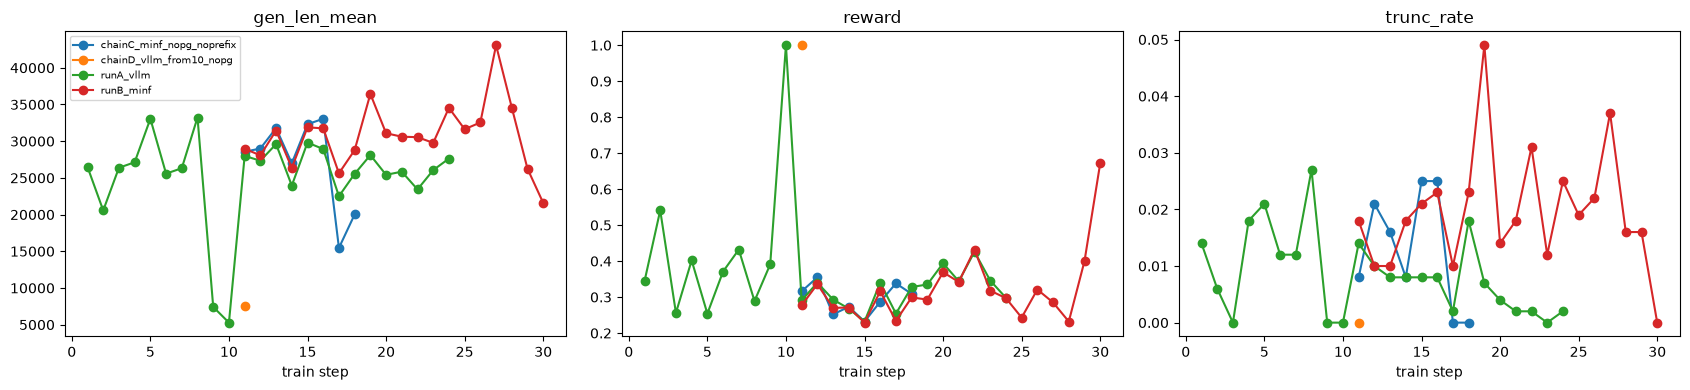

In [8]:
if HAVE_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    for run, d in PS.reset_index().groupby("short_run"):
        for ax, col in zip(axes, ["gen_len_mean", "reward", "trunc_rate"]):
            ax.plot(d["train_step"], d[col], marker="o", label=run); ax.set_title(col); ax.set_xlabel("train step")
    axes[0].legend(fontsize=7); plt.tight_layout()


### Group view for one step

Pass rate, success/failure lengths and advantages per prompt group (advantages come from the token rows).

In [9]:
def groups(run, train_step):
    exp = RUNS.get(run, run)
    r = R[(R.run == exp) & (R.train_step == train_step)]
    t = T[(T.run == exp) & (T.train_step == train_step)][["sample_id", "adv", "n_gen_tokens", "sample_mask_after", "lp_err_mean", "seq_mult_prob_error"]]
    m = r.merge(t, on="sample_id", how="left")
    rows = []
    for (gid, inst), d in m.groupby(["group_id", "instance_id"]):
        rows.append(dict(group_id=gid, instance_id=inst, n=len(d), pass_rate=d.reward.mean(),
                         L_succ=d.loc[d.reward > 0, "gen_len"].mean(), L_fail=d.loc[d.reward <= 0, "gen_len"].mean(),
                         adv_min=d.adv.min(), adv_max=d.adv.max(), turns=d.turns.mean(), trunc=int(d.truncated.sum()),
                         masked=int((d.sample_mask_after == 0).sum()), errors=dict(Counter(d.agent_error_kind.dropna()))))
    return pd.DataFrame(rows).sort_values("pass_rate")

G = groups("runB_minf", 13)
G.head(40)


,group_id,instance_id,n,pass_rate,L_succ,L_fail,adv_min,adv_max,turns,trunc,masked,errors
0,0d4a9fac-972a-4013-ba34-ac232a56b1bc,pyccel__pyccel-2238,16,0.0000,NaN,44712.125000,0.000000,0.000000,187.0000,0,0,{'max_iteration': 10}
28,e94c99c8-ef2c-4543-8b6a-6fbcde7bced7,vlucas__frisby-440,16,0.0000,NaN,24337.250000,0.000000,0.000000,61.1250,0,0,{}
25,d2b91094-eb45-4831-9f7c-651222bfff32,jonase__eastwood-352,16,0.0000,NaN,49674.750000,0.000000,0.000000,125.3125,2,0,"{'context_window': 3, 'max_iteration': 2}"
22,beb550e0-34bf-4cfa-b716-7a01c18bbbb3,dask__dask-9285,16,0.0000,NaN,35514.812500,0.000000,0.000000,120.9375,0,0,{}
21,bd90c68d-4568-4fb4-a90e-537e8c6155b2,crypto-org-chain__chain-main-477,16,0.0000,NaN,50470.375000,0.000000,0.000000,126.3125,1,0,{'context_window': 4}
20,a6d947c6-c4a1-44cd-b9dc-3f632482d56e,vyperlang__vyper-3174,16,0.0000,NaN,33179.312500,0.000000,0.000000,169.5000,0,0,{'max_iteration': 6}
17,798c5fe9-d1a8-4334-b1d4-c5cb501bd35e,juliaplots__makie.jl-2124,16,0.0000,NaN,41600.750000,0.000000,0.000000,153.1875,0,1,{'max_iteration': 4}
16,7599b4ce-85aa-4dac-8181-07ef3753830a,jump-dev__jump.jl-2550,16,0.0000,NaN,42108.437500,0.000000,0.000000,159.7500,0,0,{'max_iteration': 2}
14,7259a125-1581-4349-bb57-a78264368e03,busyorg__busy-989,16,0.0000,NaN,9999.562500,0.000000,0.000000,47.3125,0,0,{}
10,44578cf8-2151-440e-aa0d-c9177a5753c6,primefaces__primefaces-13055,16,0.0000,NaN,14368.375000,0.000000,0.000000,60.9375,0,0,{}


## Raw rollouts (streamed from the jsonl dumps)

`iter_rollouts` streams a step file (10 GB), `get_rollout` stops at the first match, `show_rollout` prints the turn structure from the Gym result: reasoning text, assistant message, tool call (with the raw `generation_str`), tool output.

In [10]:
def iter_rollouts(run, train_step):
    path = f"{run_dir(run)}/dumps/rollouts/target_step_{train_step - 1:05d}.jsonl"
    with open(path, "rb") as fh:
        for line in fh:
            if line.strip():
                yield json.loads(line)

def get_rollout(run, train_step, sample_id=None, instance_id=None, completion_index=None):
    for r in iter_rollouts(run, train_step):
        if sample_id is not None and r["sample_id"] == sample_id:
            return r
        if instance_id is not None and r["prompt_metadata"].get("instance_id") == instance_id and (completion_index is None or r["completion_index"] == completion_index):
            return r
    return None

def item_text(o):
    c = o.get("content")
    if isinstance(c, list):
        return "".join(str(p.get("text", "")) for p in c if isinstance(p, dict))
    if c is None and o.get("summary"):
        return "".join(str(p.get("text", "")) for p in o["summary"] if isinstance(p, dict))
    return str(c if c is not None else o.get("output", ""))

def output_items(r):
    return ((r.get("full_result") or {}).get("response") or {}).get("output") or []

def turn_generations(r):
    return [o.get("generation_str") or "" for o in output_items(r) if o.get("type") == "function_call"]

def show_rollout(r, max_items=40, max_chars=600):
    fr = r.get("full_result") or {}
    print(f"sample {r['sample_id']}  instance {r['prompt_metadata'].get('instance_id')}  train_step {r['target_step'] + 1}  reward {r['reward']}  "
          f"gen_len {r['generation_length']}  total {r['total_tokens']}  turns {r['num_assistant_turns']}  truncated {r['truncated']}  "
          f"error {fr.get('agent_error_kind')}  resolved {fr.get('resolved')}  weight_version {r['start_weight_version']}->{r['end_weight_version']}")
    print("messages:", dict(Counter(m["role"] for m in r["messages"])),
          " tokens by role:", {k: sum(m["n_tokens"] for m in r["messages"] if m["role"] == k) for k in ("system", "user", "assistant", "tool")},
          " flagged:", sum(bool(m.get("is_invalid_tool_call")) for m in r["messages"]), "invalid tool calls,",
          sum(bool(m.get("has_malformed_thinking")) for m in r["messages"]), "malformed thinking")
    out = output_items(r)
    for i, o in enumerate(out[:max_items]):
        t = o.get("type")
        if t == "function_call":
            g = o.get("generation_str") or ""
            print(f"\n[{i}] function_call {o.get('name')}  status={o.get('status')}  generation_chars={len(g)}  think_closed={'</think>' in g}")
            print("    args:", str(o.get("arguments"))[:max_chars])
        else:
            print(f"\n[{i}] {t}: {item_text(o)[:max_chars]!r}")
    if len(out) > max_items:
        print(f"\n... {len(out) - max_items} more items")

r0 = next(iter_rollouts("runB_minf", 13))
show_rollout(r0, max_items=10)


sample 1433bd00-b257-404a-a77a-b17cc50d6cb9_g0  instance nerzal__gocloak-194  train_step 13  reward 0.0  gen_len 7773  total 34894  turns 45  truncated False  error None  resolved False  weight_version 11->12
messages: {'user': 45, 'assistant': 45}  tokens by role: {'system': 0, 'user': 27121, 'assistant': 7773, 'tool': 0}  flagged: 0 invalid tool calls, 0 malformed thinking

[0] reasoning: 'Let me start by exploring the repository structure to understand the codebase and find where the existing session-related API calls are implemented.'

[1] message: '\n'

[2] function_call execute_bash  status=completed  generation_chars=350  think_closed=True
    args: {"command": "find /gocloak -type f -name \"*.go\" | head -30", "security_risk": "LOW"}

[3] function_call_output: '/gocloak/client_test.go\n/gocloak/models.go\n/gocloak/token.go\n/gocloak/pkg/jwx/models.go\n/gocloak/pkg/jwx/jwx.go\n/gocloak/errors.go\n/gocloak/client.go\n/gocloak/model_test.go\n/gocloak/client_benchmark_test.go\n/goc

In [11]:
def long_turns(run, train_step, min_chars=20000, limit=25):
    rows = []
    for r in iter_rollouts(run, train_step):
        for k, g in enumerate(turn_generations(r)):
            if len(g) >= min_chars:
                rows.append(dict(sample_id=r["sample_id"], instance=r["prompt_metadata"].get("instance_id"), turn=k, chars=len(g),
                                 reward=r["reward"], think_closed="</think>" in g, has_tool_call="<tool_call>" in g,
                                 error=(r.get("full_result") or {}).get("agent_error_kind")))
    return pd.DataFrame(rows).sort_values("chars", ascending=False).head(limit)

# scans a whole step file (~10 GB, a few minutes); uncomment to run
# long_turns("runB_minf", 13)


## Token-level dumps

Each chunk holds ~170 sequences: flat `input_ids` / `token_mask` with per-sequence `input_lengths`, and `generation_logprobs` / `prev_logprobs` / `advantages` with `input_lengths - 1` entries per sequence (entry j scores token j+1). `token_mask` marks generated tokens.

In [12]:
def load_chunk(path):
    d = load_pt(path)
    lengths = np.asarray(d["input_lengths"]).astype(np.int64)
    d["_ids_off"] = np.concatenate([[0], np.cumsum(lengths)])
    d["_lp_off"] = np.concatenate([[0], np.cumsum(lengths - 1)])
    return d

def sequence(d, i):
    a, b = d["_ids_off"][i], d["_ids_off"][i + 1]
    c, e = d["_lp_off"][i], d["_lp_off"][i + 1]
    tags = d.get("tags") or [{}] * len(d["sample_ids"])
    return dict(sample_id=d["sample_ids"][i], tags=tags[i], reward=float(d["rewards"][i]),
                ids=np.asarray(d["input_ids"])[a:b],
                gen=np.asarray(d["token_mask"])[a + 1:b].astype(bool),
                gen_lp=np.asarray(d["generation_logprobs"])[c:e].astype(np.float32),
                prev_lp=np.asarray(d["prev_logprobs"])[c:e].astype(np.float32),
                adv=np.asarray(d["advantages"])[c:e].astype(np.float32),
                sample_mask_before=float(d["sample_mask_before"][i]), sample_mask_after=float(d["sample_mask_after"][i]),
                seq_mult_prob_error=float(d["seq_mult_prob_error"][i]))

def find_sample(run, train_step, sample_id):
    for p in token_files(run, train_step):
        d = load_chunk(p)
        ids = list(d["sample_ids"])
        if sample_id in ids:
            return sequence(d, ids.index(sample_id))
    return None

try:
    from tokenizers import Tokenizer
    TOK = Tokenizer.from_file(f"{RUNS_ROOT}/nano35-swe-v2-stream128-inorder1-cmh-64n-minf/checkpoints/step_55/hf/tokenizer.json")
    def decode(ids):
        return TOK.decode([int(x) for x in ids], skip_special_tokens=False)
except Exception as exc:
    TOK = None
    print("tokenizer not importable here (needs the `tokenizers` package):", exc)
    def decode(ids):
        return "<tokenizer unavailable>"

files = token_files("runB_minf", 13)
print(len(files), "chunks;", [os.path.basename(f) for f in files])


3 chunks; ['step_00013_chunk_001.pt', 'step_00013_chunk_002.pt', 'step_00013_chunk_003.pt']


1433bd00-b257-404a-a77a-b17cc50d6cb9_g0 tags {'weight_version': 11, 'rollout_environment': 'swe_agents_train', 'rollout_generation_length': 7773, 'rollout_reward': 0.0, 'rollout_truncated': False, 'rollout_env_extra:reward': 0.0, 'rollout_env_extra:resolved': 0.0, 'rollout_env_extra:patch_exists': 1.0, 'rollout_env_extra:agent_peak_rss_mb': 887.0, 'rollout_env_extra:eval_peak_rss_mb': 17.0, 'rollout_env_extra:ray_queue_time': 0.07173848152160645, 'rollout_env_extra:openhands_run_time': 156.47167491912842, 'rollout_env_extra:generation_apptainer_spinup_time': 1.6368417739868164, 'rollout_env_extra:create_runtime_time': 0.007237994985189289, 'rollout_env_extra:connect_to_runtime_time': 13.001432871009456, 'rollout_env_extra:initialize_runtime_time': 2.379781739000464, 'rollout_env_extra:total_command_exec_time': 24.80135941505432, 'rollout_env_extra:total_model_call_time': 94.7306637763977, 'rollout_env_extra:final_eval_apptainer_spinup_time': 2.154036521911621, 'rollout_env_extra:final_

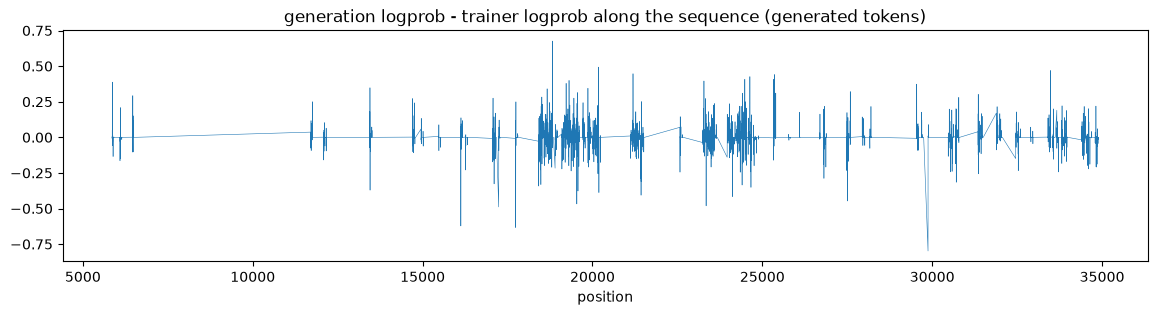

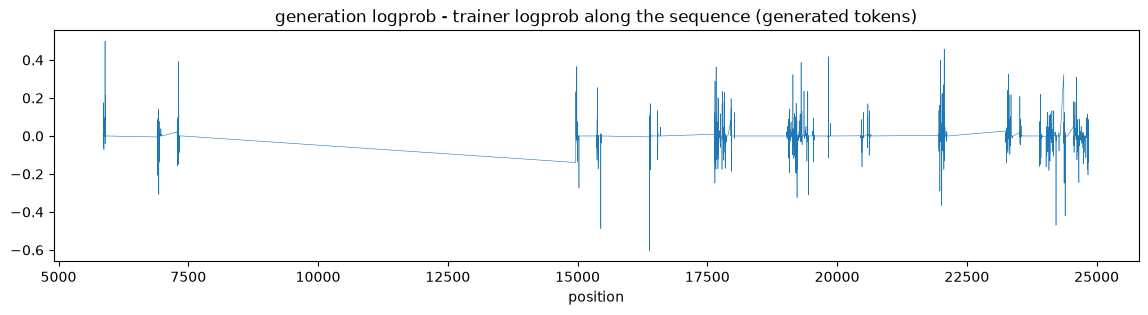

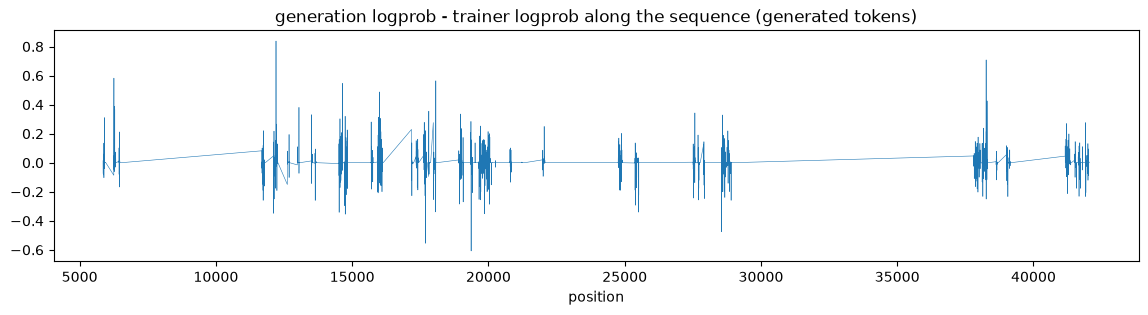

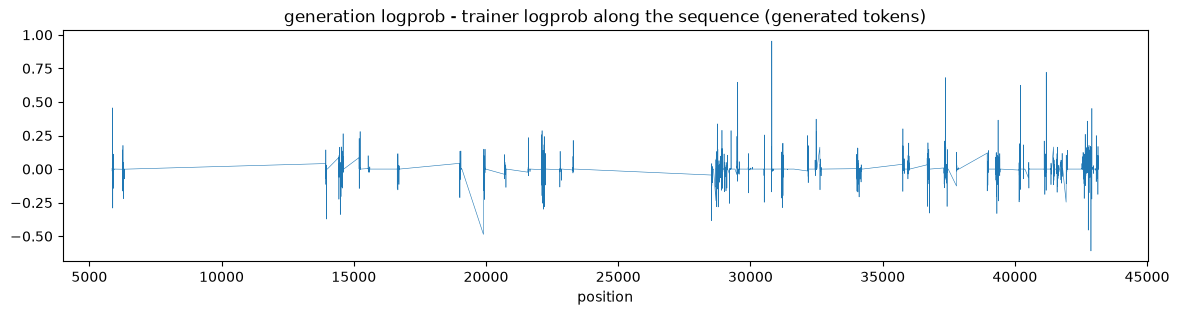

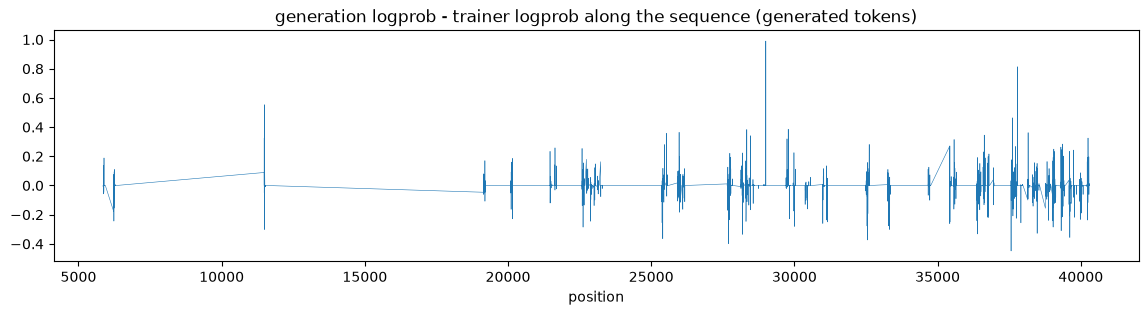

In [13]:
import itertools
for r0 in itertools.islice(iter_rollouts("runB_minf", 13), 5):
    s = find_sample("runB_minf", 13, r0["sample_id"])
    if s:
        g = s["gen"]
        print(s["sample_id"], "tags", s["tags"])
        print(f"tokens {len(s['ids'])}  generated {int(g.sum())}  reward {s['reward']}  adv {s['adv'][g][0]:+.3f}  mask_after {s['sample_mask_after']}")
        print(f"mean gen_lp {s['gen_lp'][g].mean():+.4f}  mean prev_lp {s['prev_lp'][g].mean():+.4f}  mean(gen-prev) {(s['gen_lp'] - s['prev_lp'])[g].mean():+.5f}  seq_mult_prob_error {s['seq_mult_prob_error']:.4f}")
        err = np.abs(s["gen_lp"] - s["prev_lp"]) * g
        for j in np.argsort(-err)[:8]:
            print(f"  pos {j:6d}  token {decode(s['ids'][j + 1:j + 2])!r:20}  gen_lp {s['gen_lp'][j]:+.3f}  prev_lp {s['prev_lp'][j]:+.3f}")
        if HAVE_MPL:
            fig, ax = plt.subplots(figsize=(14, 3))
            pos = np.arange(len(s["gen_lp"]))[g]
            ax.plot(pos, (s["gen_lp"] - s["prev_lp"])[g], lw=0.4); ax.set_title("generation logprob - trainer logprob along the sequence (generated tokens)"); ax.set_xlabel("position")


caf6f45d-123b-4e21-ac10-719e9ac61f3c_g0 tags {'weight_version': 0, 'rollout_environment': 'swe_agents_train', 'rollout_generation_length': 10637, 'rollout_reward': 0.0, 'rollout_truncated': False, 'rollout_env_extra:reward': 0.0, 'rollout_env_extra:resolved': 0.0, 'rollout_env_extra:patch_exists': 1.0, 'rollout_env_extra:agent_peak_rss_mb': 5023.0, 'rollout_env_extra:ray_queue_time': 2.036914587020874, 'rollout_env_extra:openhands_run_time': 345.58845019340515, 'rollout_env_extra:generation_apptainer_spinup_time': 1.6182301044464111, 'rollout_env_extra:create_runtime_time': 0.007203479006420821, 'rollout_env_extra:connect_to_runtime_time': 12.942113358993083, 'rollout_env_extra:initialize_runtime_time': 2.8878763359971344, 'rollout_env_extra:total_command_exec_time': 100.49254608154297, 'rollout_env_extra:total_model_call_time': 200.9657781124115, 'rollout_env_extra:final_eval_apptainer_spinup_time': 1.7615461349487305, 'rollout_env_extra:final_eval_time': 5.898723840713501}
tokens 401

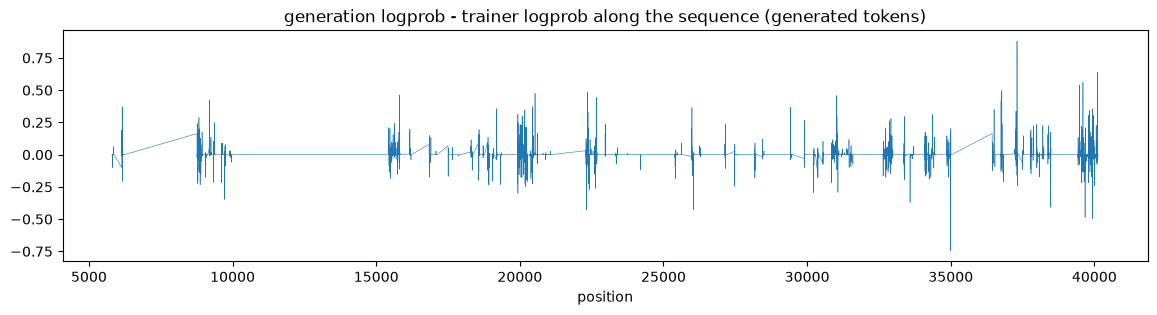

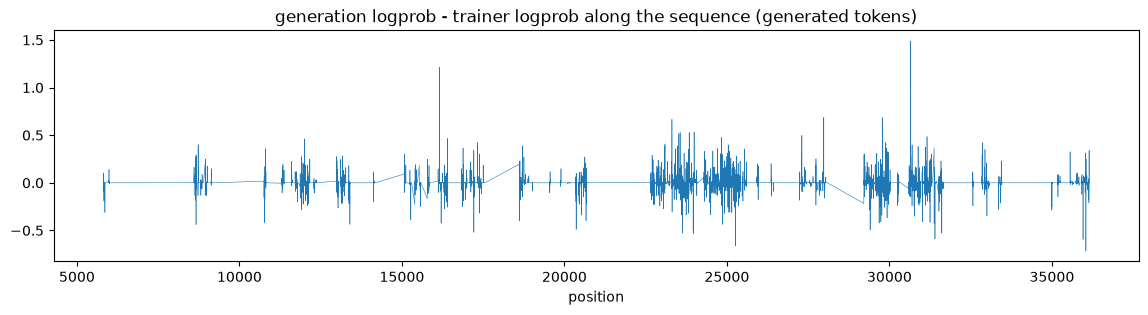

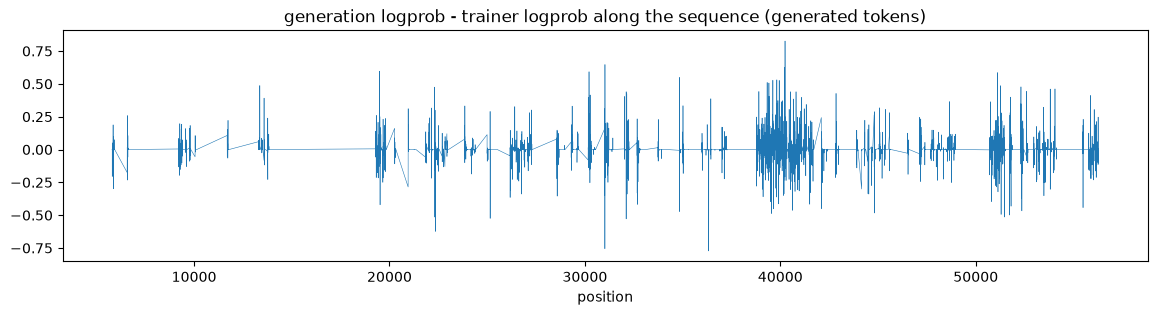

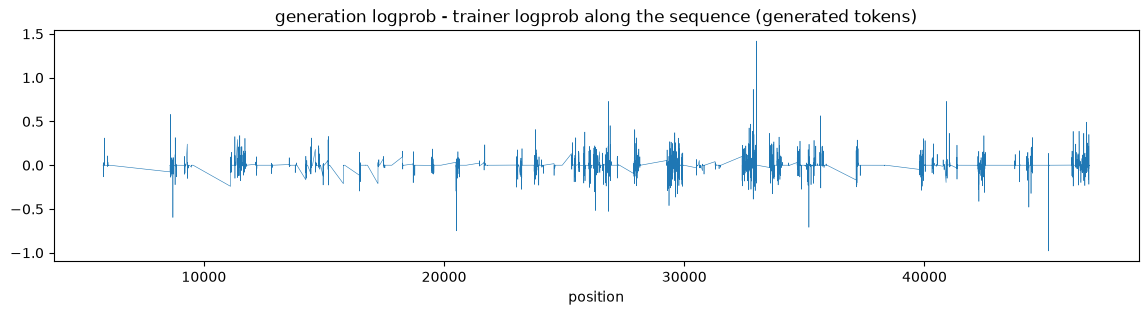

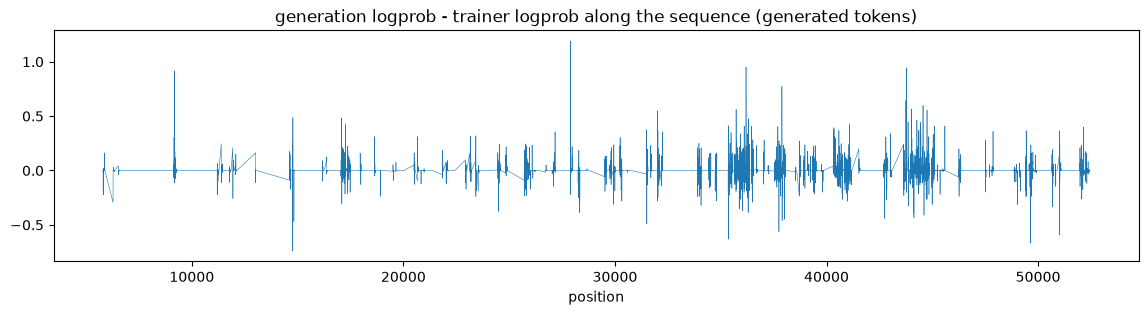

In [15]:
import itertools
step = 1
for r0 in itertools.islice(iter_rollouts("runA_vllm", step), 5):
    s = find_sample("runA_vllm", step, r0["sample_id"])
    if s:
        g = s["gen"]
        print(s["sample_id"], "tags", s["tags"])
        print(f"tokens {len(s['ids'])}  generated {int(g.sum())}  reward {s['reward']}  adv {s['adv'][g][0]:+.3f}  mask_after {s['sample_mask_after']}")
        print(f"mean gen_lp {s['gen_lp'][g].mean():+.4f}  mean prev_lp {s['prev_lp'][g].mean():+.4f}  mean(gen-prev) {(s['gen_lp'] - s['prev_lp'])[g].mean():+.5f}  seq_mult_prob_error {s['seq_mult_prob_error']:.4f}")
        err = np.abs(s["gen_lp"] - s["prev_lp"]) * g
        for j in np.argsort(-err)[:8]:
            print(f"  pos {j:6d}  token {decode(s['ids'][j + 1:j + 2])!r:20}  gen_lp {s['gen_lp'][j]:+.3f}  prev_lp {s['prev_lp'][j]:+.3f}")
        if HAVE_MPL:
            fig, ax = plt.subplots(figsize=(14, 3))
            pos = np.arange(len(s["gen_lp"]))[g]
            ax.plot(pos, (s["gen_lp"] - s["prev_lp"])[g], lw=0.4); ax.set_title("generation logprob - trainer logprob along the sequence (generated tokens)"); ax.set_xlabel("position")


### Generation-vs-trainer logprob error histograms (from `*.hist.json`)

In [16]:
H = pd.DataFrame([json.load(open(f)) for f in sorted(glob.glob(f"{ANALYSIS}/tokens/*.hist.json"))])
H["train_step"] = H["file"].str.extract(r"step_(\d+)").astype(int)
H["short_run"] = H["run"].map(EXP2RUN).fillna(H["run"])
bins = H["lp_err_bins"].iloc[0]
agg = {run: np.sum(np.vstack(d["lp_err_hist"].values), axis=0) for run, d in H.groupby("short_run")}
pd.DataFrame({run: v / v.sum() for run, v in agg.items()}, index=[f"[{bins[i]}, {bins[i + 1]})" for i in range(len(bins) - 1)]).round(6)


,chainC_minf_nopg_noprefix,runA_vllm,runB_minf
"[0, 0.0001)",0.681372,0.682812,0.653985
"[0.0001, 0.001)",0.072709,0.071604,0.076909
"[0.001, 0.01)",0.086934,0.085645,0.094322
"[0.01, 0.05)",0.073782,0.073142,0.081254
"[0.05, 0.1)",0.035402,0.035275,0.039173
"[0.1, 0.25)",0.039637,0.040236,0.043544
"[0.25, 0.5)",0.008730,0.009591,0.009352
"[0.5, 1)",0.001347,0.001585,0.001373
"[1, 2)",0.000084,0.000105,0.000083
"[2, 5)",0.000004,0.000005,0.000004


## W&B scalars (cached pulls)

`wandb_step_metrics_full.json` holds main_minf / runA_vllm / runB_minf; `wandb_engine_compare.json` holds the vLLM baseline (`vllm_base`), the main MINF chain and a second vLLM run. Refresh with the GraphQL pull used before (needs `WANDB_API_KEY` in the environment; never print it).

In [ ]:
def load_wandb():
    frames = []
    for f in sorted(glob.glob(f"{ANALYSIS}/wandb_*.json")):
        d = json.load(open(f))
        for run, steps in d.items():
            if not isinstance(steps, dict):
                continue
            df = pd.DataFrame.from_dict(steps, orient="index")
            df.index = df.index.astype(int); df.index.name = "train_step"
            df["run"] = run; df["source"] = os.path.basename(f)
            frames.append(df.reset_index())
    return pd.concat(frames, ignore_index=True)

WB = load_wandb()
KEYS = ["train/reward", "train/rollout_length/swe_agents_train/mean", "train/rollout_length/swe_agents_train/truncation_rate",
        "train/advantages/mean", "train/gen_kl_error", "train/total_num_tokens", "train/num_masked_seqs_by_logprob_error"]
WB[WB.source == "wandb_engine_compare.json"].pivot_table(index="train_step", columns="run", values="train/advantages/mean").head(30)


In [ ]:
if HAVE_MPL:
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    for ax, key in zip(axes.flat, ["train/rollout_length/swe_agents_train/mean", "train/reward", "train/advantages/mean", "train/gen_kl_error"]):
        for (src, run), d in WB.groupby(["source", "run"]):
            if key in d and d[key].notna().any():
                ax.plot(d["train_step"], d[key], marker=".", lw=0.8, label=f"{run} ({src.split('_')[1]})")
        ax.set_title(key); ax.set_xlabel("train step")
    axes[0, 0].legend(fontsize=6); plt.tight_layout()


## Gym per-instance results (for runs without dumps, e.g. the main MINF chain)

One directory per rollout; `nemo_gym_metrics.json` has `resolved`, per-turn token usage (`completion_tokens` equals the trained generation length), timings and `agent_error_kind`. Sessions map to Slurm segments by mtime.

In [ ]:
def gym_sessions(root=GYM_MAIN):
    s = sorted(glob.glob(f"{root}/swebench_results_*"), key=os.path.getmtime)
    return pd.DataFrame([(os.path.basename(p), len(os.listdir(p)), pd.Timestamp(os.path.getmtime(p), unit="s", tz="America/Los_Angeles")) for p in s],
                        columns=["session", "instances", "last_write"])

def gym_results_df(session_dir, limit=None):
    rows = []
    for d in os.scandir(session_dir):
        p = os.path.join(d.path, "nemo_gym_metrics.json")
        if not os.path.exists(p):
            continue
        j = json.load(open(p))
        m = re.match(r"^(.*)_(\d{13})_([0-9a-f]{8})$", d.name)
        u = ((j.get("per_turn_metrics") or {}).get("accumulated_token_usage") or {})
        rows.append(dict(instance=m.group(1) if m else d.name, resolved=j.get("resolved"), completion_tokens=u.get("completion_tokens"),
                         prompt_tokens=u.get("prompt_tokens"), turns=len((j.get("per_turn_metrics") or {}).get("token_usages") or []),
                         error=j.get("agent_error_kind"), start=j.get("generation_start_timestamp"), run_time=j.get("openhands_run_time"), dir=d.name))
        if limit and len(rows) >= limit:
            break
    return pd.DataFrame(rows)

gym_sessions()


In [ ]:
# main MINF chain, segment 1 (train steps 1-8, 2026-09-16 07:53-11:53 PDT) -- ~1 min to scan
# GM = gym_results_df(f"{GYM_MAIN}/swebench_results_1789570827574_f7cb6b6f")
# GM.groupby("resolved")["completion_tokens"].describe()


## Early-step engine comparison (steps 1-8, same prompts, same weights)

Output of `tools/early_step_compare.py` / `tools/early_step_mixed.py`: per prompt, run A (vLLM, `A_*`) against the main MINF chain (`M_*`).

In [ ]:
EP = pd.read_csv(f"{ANALYSIS}/early_steps/per_prompt.csv")
EP["dL_rel"] = (EP.M_meanL - EP.A_meanL) / EP.A_meanL
EP["d_pass"] = EP.M_k / EP.M_n - EP.A_k / EP.A_n
EP.groupby("step")[["dL_rel", "d_pass"]].agg(["mean", "median", "count"]).round(3)


## Other tools in `swe_dump/tools/`

- `aggregate_dumps.py` (engine-level aggregate report), `token_deep.py` + `aggregate_deep.py` (per-token category / position / turn stats), `parser_ab.py` (re-parse every turn with both tool parsers)
- `runaway_detail.py`, `inspect_row.py`, `message_turns.py`, `user_message_context.py`, `error_strings.py` (single-rollout inspection helpers)
- `early_step_compare.py`, `early_step_mixed.py` (this notebook's last section)
